# Evaluation & Metrics — Knowing When Your Model is Actually Good

You've trained a model. It says it's 95% accurate. Great... or is it?

This notebook is about **not being fooled by numbers**. We'll cover the full toolkit of evaluation metrics — what they measure, when to use them, and when they lie to you. By the end, you'll know exactly which metric to reach for in any interview (or real project) scenario.

---

## 📚 What You'll Learn

1. The Confusion Matrix — the foundation of everything
2. Classification Metrics: Accuracy, Precision, Recall, F1, ROC-AUC
3. The Accuracy Paradox — why accuracy is often useless
4. Regression Metrics: MAE, MSE, RMSE, R², MAPE
5. Ranking Metrics: Precision@K, NDCG (for search/recommendations)
6. Calibration — do your probabilities actually mean anything?
7. Cross-Validation — evaluating *reliably*
8. How to choose the right metric — a practical decision guide
9. Interview Q&A

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
print("✅ Libraries loaded!")

✅ Libraries loaded!


---
## 1. The Confusion Matrix — The Foundation

Before any metric, we need to understand what our model actually does with each prediction. For binary classification, every prediction falls into one of four buckets:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actually Positive** | ✅ True Positive (TP) | ❌ False Negative (FN) |
| **Actually Negative** | ❌ False Positive (FP) | ✅ True Negative (TN) |

**Intuition with a medical example:**
- **TP**: Patient has cancer, model says cancer → caught it ✅
- **FN**: Patient has cancer, model says no cancer → missed it, dangerous ❌
- **FP**: Patient is healthy, model says cancer → unnecessary stress/treatment ❌  
- **TN**: Patient is healthy, model says healthy → correct ✅

Every metric below is just a different way of combining these four numbers.

TP=5, TN=5, FP=2, FN=3


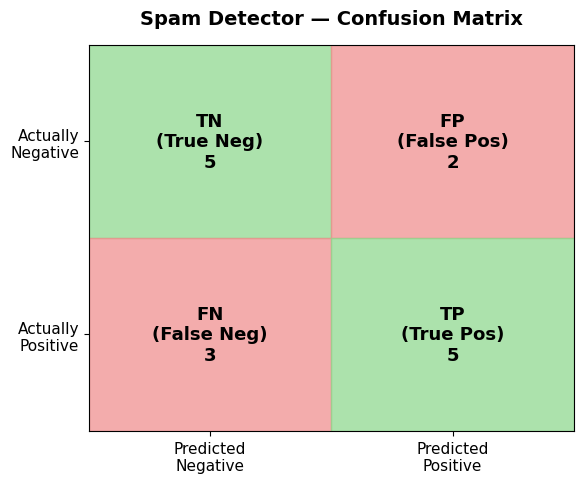

In [2]:
def confusion_matrix_from_scratch(y_true, y_pred):
    """Compute confusion matrix without sklearn."""
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def plot_confusion_matrix(TP, TN, FP, FN, title="Confusion Matrix"):
    cm = np.array([[TN, FP], [FN, TP]])
    labels = np.array([['TN\n(True Neg)', 'FP\n(False Pos)'],
                        ['FN\n(False Neg)', 'TP\n(True Pos)']])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = np.array([[0.55, 0.85, 0.55], [0.95, 0.55, 0.55],
                        [0.95, 0.55, 0.55], [0.55, 0.85, 0.55]])
    colors = colors.reshape(2, 2, 3)
    
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, color=colors[i,j], alpha=0.7))
            ax.text(j+0.5, 1.5-i, f"{labels[i,j]}\n{cm[i,j]}",
                    ha='center', va='center', fontsize=13, fontweight='bold')
    
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Predicted\nNegative', 'Predicted\nPositive'], fontsize=11)
    ax.set_yticklabels(['Actually\nPositive', 'Actually\nNegative'], fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

# Example: email spam detector
y_true = np.array([1,1,1,1,1, 0,0,0,0,0, 1,0,1,0,1])
y_pred = np.array([1,1,1,0,0, 0,0,0,1,1, 1,0,0,0,1])

TP, TN, FP, FN = confusion_matrix_from_scratch(y_true, y_pred)
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
plot_confusion_matrix(TP, TN, FP, FN, title="Spam Detector — Confusion Matrix")

---
## 2. Classification Metrics — Built From the Confusion Matrix

### 2.1 Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

The fraction of all predictions that were correct. Simple, intuitive... and often misleading.

---

### 2.2 Precision — "Of what I flagged, how many were right?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

Use when **false positives are costly**: spam filters (don't delete real emails), fraud alerts (don't block real customers).

---

### 2.3 Recall (Sensitivity) — "Of all the real positives, how many did I catch?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

Use when **false negatives are costly**: cancer detection (don't miss sick patients), fraud detection (don't miss fraud).

---

### 2.4 F1 Score — The harmonic mean of Precision and Recall

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Why harmonic mean and not regular average? Because it punishes extreme imbalance. If Precision=1.0 and Recall=0.01, the regular average is 0.505 (sounds ok!), but F1=0.02 (terrible, as it should be).

**F-beta score** lets you weight one over the other:
$$F_\beta = (1+\beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

- $\beta > 1$: penalize missed recalls more (use for disease detection)
- $\beta < 1$: penalize false positives more (use for spam)

📊 Metrics from scratch:
   Accuracy    : 0.667
   Precision   : 0.714
   Recall      : 0.625
   F1          : 0.667
   F2.0        : 0.641


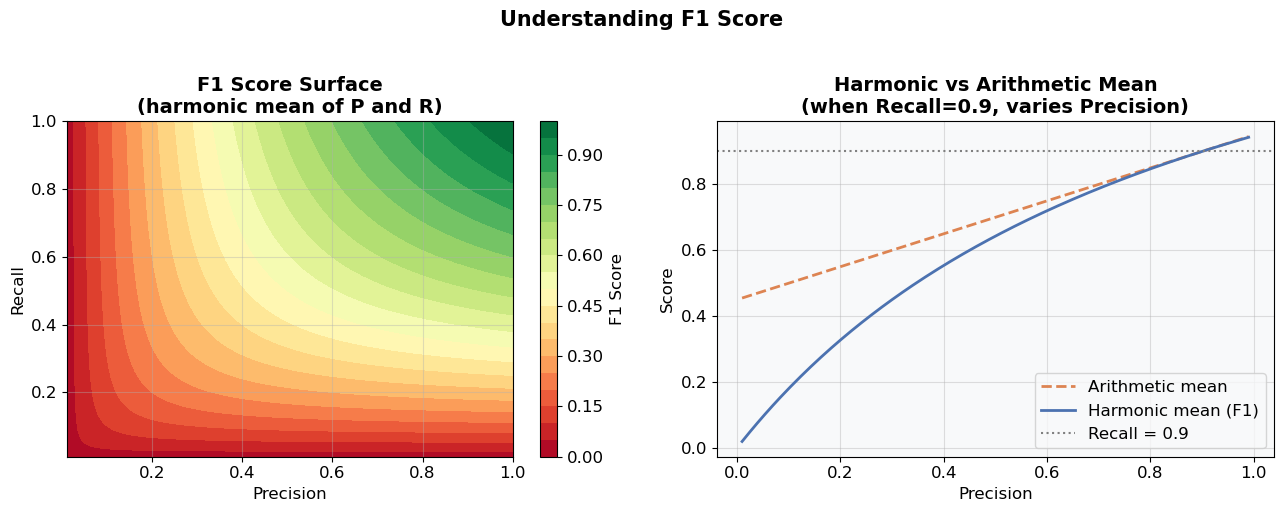

In [3]:
def metrics_from_scratch(y_true, y_pred, beta=1.0):
    TP, TN, FP, FN = confusion_matrix_from_scratch(y_true, y_pred)
    
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f_beta    = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (precision + recall) > 0 else 0
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, f'F{beta}': f_beta}

results = metrics_from_scratch(y_true, y_pred, beta=2.0)
print("📊 Metrics from scratch:")
for name, val in results.items():
    print(f"   {name:12s}: {val:.3f}")

# Why harmonic mean matters — visualize P/R tradeoff
precisions = np.linspace(0.01, 1.0, 100)
recalls_fixed = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: F1 surface
P, R = np.meshgrid(np.linspace(0.01,1,200), np.linspace(0.01,1,200))
F1 = 2*P*R / (P+R)
c = axes[0].contourf(P, R, F1, levels=20, cmap='RdYlGn')
plt.colorbar(c, ax=axes[0], label='F1 Score')
axes[0].set_xlabel('Precision'); axes[0].set_ylabel('Recall')
axes[0].set_title('F1 Score Surface\n(harmonic mean of P and R)')

# Right: arithmetic vs harmonic mean comparison
P_range = np.linspace(0.01, 0.99, 200)
R_fixed = 0.9
arith = (P_range + R_fixed) / 2
harmo = 2 * P_range * R_fixed / (P_range + R_fixed)
axes[1].plot(P_range, arith, label='Arithmetic mean', color=COLORS[1], linewidth=2, linestyle='--')
axes[1].plot(P_range, harmo, label='Harmonic mean (F1)', color=COLORS[0], linewidth=2)
axes[1].axhline(R_fixed, color='gray', linestyle=':', label=f'Recall = {R_fixed}')
axes[1].set_xlabel('Precision'); axes[1].set_ylabel('Score')
axes[1].set_title('Harmonic vs Arithmetic Mean\n(when Recall=0.9, varies Precision)')
axes[1].legend()

plt.suptitle('Understanding F1 Score', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. The Accuracy Paradox 🚨

This is one of the most common interview traps. Here's the scenario:

> You're building a fraud detector. 99% of transactions are legit, 1% are fraud.  
> A model that **always predicts "not fraud"** gets **99% accuracy**.  
> Is it a good model?

Obviously not — it catches zero fraud. But accuracy says it's great. This is the **accuracy paradox**, and it happens whenever classes are imbalanced.


  Lazy Model (always 'not fraud')
  TP=0, TN=9900, FP=0, FN=100
  Accuracy : 0.9900  
  Precision: 0.0000
  Recall   : 0.0000
  F1       : 0.0000
  Fraud caught: 0/100 (0%)

  Smart Model (real detector)
  TP=80, TN=9850, FP=50, FN=20
  Accuracy : 0.9930  
  Precision: 0.6154
  Recall   : 0.8000
  F1       : 0.6957
  Fraud caught: 80/100 (80%)


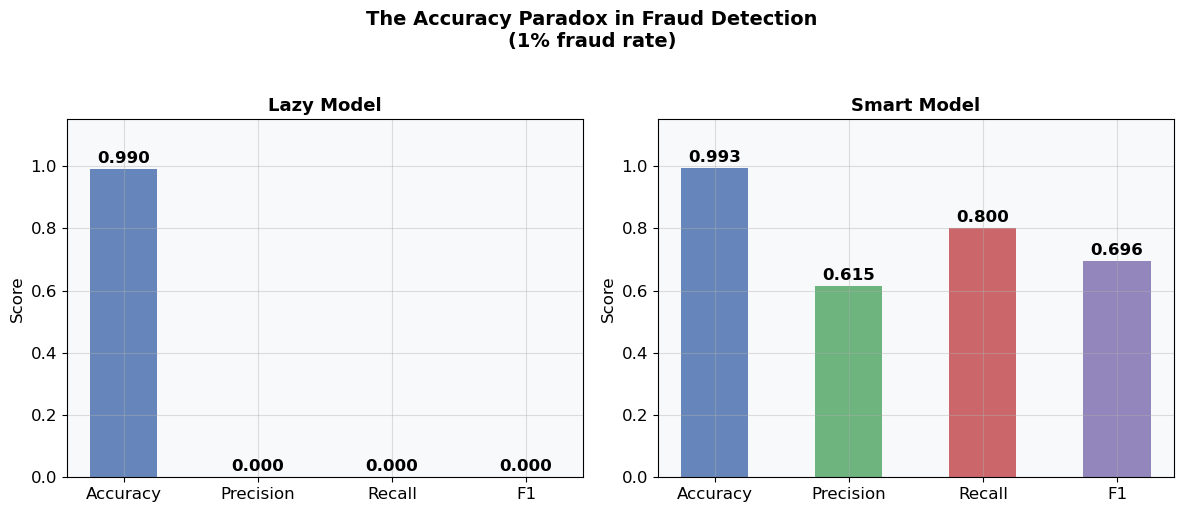


💡 Key takeaway: Lazy model has 99% accuracy but catches ZERO fraud!


In [4]:
# Simulate the accuracy paradox
np.random.seed(42)
n = 10000
fraud_rate = 0.01  # 1% fraud

y_true_fraud = np.array([1]*int(n*fraud_rate) + [0]*int(n*(1-fraud_rate)))

# Model A: always predicts "not fraud"
y_lazy = np.zeros(len(y_true_fraud), dtype=int)

# Model B: a real model (catches 80% of fraud with some false positives)
y_smart = y_true_fraud.copy()
fraud_idx = np.where(y_true_fraud == 1)[0]
missed = np.random.choice(fraud_idx, size=int(len(fraud_idx)*0.2), replace=False)
y_smart[missed] = 0
legit_idx = np.where(y_true_fraud == 0)[0]
false_alarms = np.random.choice(legit_idx, size=50, replace=False)
y_smart[false_alarms] = 1

def full_report(y_true, y_pred, name):
    TP, TN, FP, FN = confusion_matrix_from_scratch(y_true, y_pred)
    m = metrics_from_scratch(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  TP={TP}, TN={TN}, FP={FP}, FN={FN}")
    print(f"  Accuracy : {m['Accuracy']:.4f}  {'⚠️  MISLEADING!' if name=='Lazy Model' else ''}")
    print(f"  Precision: {m['Precision']:.4f}")
    print(f"  Recall   : {m['Recall']:.4f}")
    print(f"  F1       : {m['F1']:.4f}")
    print(f"  Fraud caught: {TP}/{TP+FN} ({TP/(TP+FN)*100:.0f}%)")

full_report(y_true_fraud, y_lazy, "Lazy Model (always 'not fraud')")
full_report(y_true_fraud, y_smart, "Smart Model (real detector)")

# Visualize the paradox
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_lazy, y_smart], ["Lazy Model", "Smart Model"]):
    TP, TN, FP, FN = confusion_matrix_from_scratch(y_true_fraud, y_pred)
    m = metrics_from_scratch(y_true_fraud, y_pred)
    
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
    values = [m['Accuracy'], m['Precision'], m['Recall'], m['F1']]
    bars = ax.bar(metrics_names, values, color=[COLORS[0], COLORS[2], COLORS[3], COLORS[4]], alpha=0.85, width=0.5)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')

plt.suptitle('The Accuracy Paradox in Fraud Detection\n(1% fraud rate)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n💡 Key takeaway: Lazy model has 99% accuracy but catches ZERO fraud!")

---
## 4. ROC Curve and AUC — The Threshold-Free View

Most classifiers don't just output "yes/no" — they output a **probability** (e.g., 0.73 chance of fraud). You then pick a **threshold** (e.g., predict fraud if prob > 0.5) to turn probabilities into decisions.

The **ROC curve** shows how your model performs at **every possible threshold**:
- X-axis: False Positive Rate = $\frac{FP}{FP + TN}$ ("how often do we wrongly alarm?")
- Y-axis: True Positive Rate (Recall) = $\frac{TP}{TP + FN}$ ("how often do we catch it?")

**AUC (Area Under the Curve)** summarizes the whole curve in one number:
- AUC = 1.0 → perfect model
- AUC = 0.5 → random guessing (the diagonal)
- AUC = 0.0 → perfectly wrong (just flip predictions!)

**Probabilistic interpretation**: AUC = the probability that a randomly chosen positive example is ranked higher than a randomly chosen negative example.

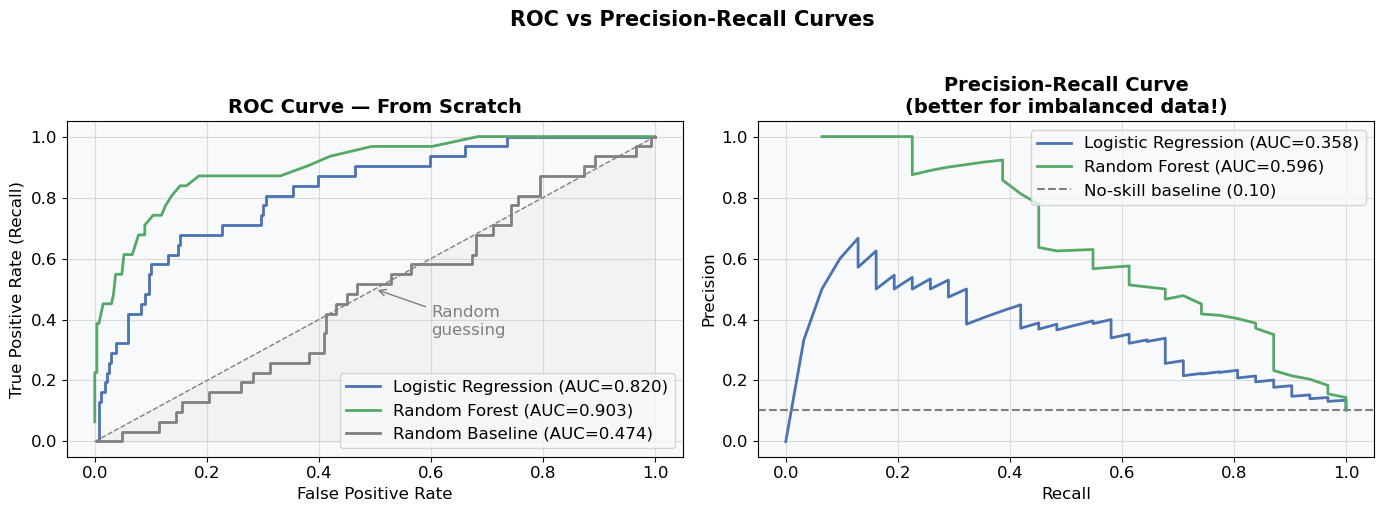

💡 PR-AUC is more informative than ROC-AUC when the dataset is imbalanced!
   ROC-AUC can look great even when the model is bad on the minority class.


In [5]:
def roc_curve_from_scratch(y_true, y_scores):
    """Compute ROC curve by sweeping all unique thresholds."""
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tprs, fprs = [], []
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        TP, TN, FP, FN = confusion_matrix_from_scratch(y_true, y_pred)
        tprs.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
        fprs.append(FP / (FP + TN) if (FP + TN) > 0 else 0)
    
    return np.array(fprs), np.array(tprs)

def auc_from_scratch(fprs, tprs):
    """Trapezoidal integration."""
    sorted_idx = np.argsort(fprs)
    return np.trapz(tprs[sorted_idx], fprs[sorted_idx])

# Generate data and train models
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            weights=[0.9, 0.1], random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

lr  = LogisticRegression(max_iter=500).fit(X_train, y_train)
rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

lr_scores = lr.predict_proba(X_test)[:, 1]
rf_scores = rf.predict_proba(X_test)[:, 1]
rand_scores = np.random.rand(len(y_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
ax = axes[0]
for scores, name, color in [(lr_scores, 'Logistic Regression', COLORS[0]),
                              (rf_scores, 'Random Forest', COLORS[2]),
                              (rand_scores, 'Random Baseline', 'gray')]:
    fprs, tprs = roc_curve_from_scratch(y_test, scores)
    auc = auc_from_scratch(fprs, tprs)
    ax.plot(fprs, tprs, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.fill_between([0,1],[0,1],[0,0], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — From Scratch'); ax.legend()
ax.annotate('Random\nguessing', xy=(0.5, 0.5), xytext=(0.6, 0.35),
            arrowprops=dict(arrowstyle='->', color='gray'), color='gray')

# --- Precision-Recall Curve ---
def pr_curve_from_scratch(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    precs, recs = [], []
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        TP, TN, FP, FN = confusion_matrix_from_scratch(y_true, y_pred)
        precs.append(TP / (TP + FP) if (TP + FP) > 0 else 1)
        recs.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    return np.array(recs), np.array(precs)

ax = axes[1]
baseline = y_test.mean()
for scores, name, color in [(lr_scores, 'Logistic Regression', COLORS[0]),
                              (rf_scores, 'Random Forest', COLORS[2])]:
    recs, precs = pr_curve_from_scratch(y_test, scores)
    pr_auc = auc_from_scratch(recs, precs)
    ax.plot(recs, precs, label=f'{name} (AUC={pr_auc:.3f})', color=color, linewidth=2)

ax.axhline(baseline, linestyle='--', color='gray', label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve\n(better for imbalanced data!)'); ax.legend()

plt.suptitle('ROC vs Precision-Recall Curves', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 PR-AUC is more informative than ROC-AUC when the dataset is imbalanced!")
print("   ROC-AUC can look great even when the model is bad on the minority class.")

---
## 5. Regression Metrics

For regression problems (predicting continuous values), we have a different toolkit.

Let $y_i$ = actual value, $\hat{y}_i$ = predicted value, $\bar{y}$ = mean of actuals.

### MAE — Mean Absolute Error
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Same units as target. Robust to outliers. Intuitive: "on average, we're off by X."

### MSE — Mean Squared Error
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Penalizes large errors heavily. Differentiable → used during training. Units are squared.

### RMSE — Root Mean Squared Error
$$\text{RMSE} = \sqrt{\text{MSE}}$$
Same units as target, but still sensitive to outliers. Most commonly reported.

### R² — Coefficient of Determination
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}}$$

Tells you: "how much of the variance in y does your model explain?"  
- $R^2 = 1$: perfect  
- $R^2 = 0$: as good as just predicting the mean  
- $R^2 < 0$: worse than predicting the mean (your model is really bad)

### MAPE — Mean Absolute Percentage Error
$$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$
Scale-independent, easy to explain to non-technical stakeholders. Breaks when $y_i = 0$.

📊 Regression Metrics from scratch:
   MAE         : 22.3585
   MSE         : 737.7588
   RMSE        : 27.1617
   R²          : 0.9108
   MAPE (%)    : 72.0900


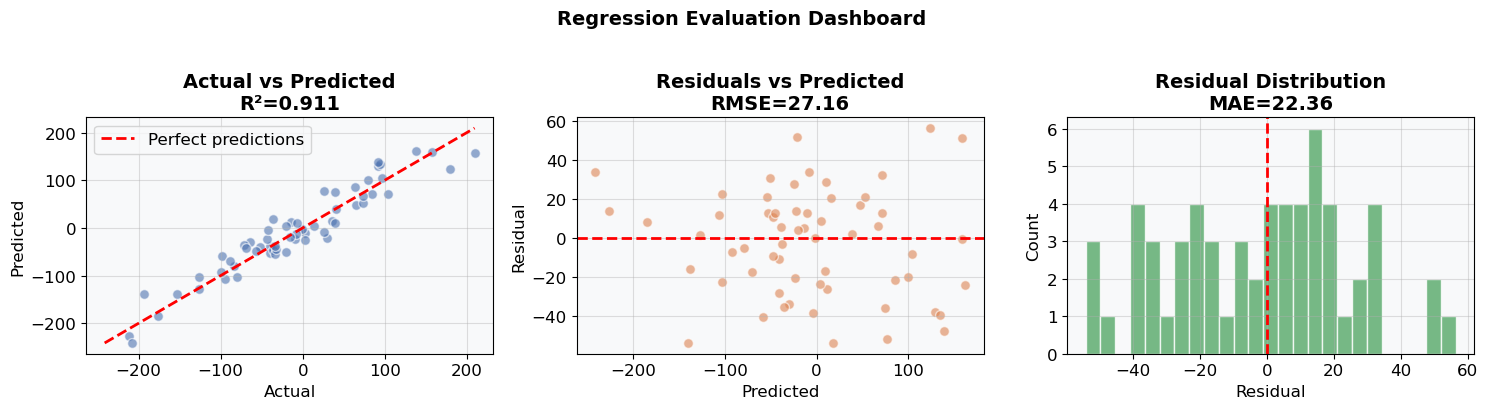


🧪 Effect of outliers on MAE vs MSE:
  No outlier                → MAE=0.6, RMSE=0.7  (RMSE jumps more!)
  With outlier (100)        → MAE=18.5, RMSE=40.3  (RMSE jumps more!)


In [6]:
def regression_metrics_from_scratch(y_true, y_pred):
    n = len(y_true)
    errors = y_true - y_pred
    
    mae  = np.mean(np.abs(errors))
    mse  = np.mean(errors**2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(errors**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2   = 1 - ss_res / ss_tot
    mape = np.mean(np.abs(errors / (y_true + 1e-8))) * 100
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}

# Generate regression data
np.random.seed(42)
X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=30, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

model = LinearRegression().fit(X_tr, y_tr)
y_pred_reg = model.predict(X_te)

metrics_reg = regression_metrics_from_scratch(y_te, y_pred_reg)
print("📊 Regression Metrics from scratch:")
for name, val in metrics_reg.items():
    print(f"   {name:12s}: {val:.4f}")

# Visualize residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
residuals = y_te - y_pred_reg

# Predicted vs Actual
axes[0].scatter(y_te, y_pred_reg, alpha=0.6, color=COLORS[0], edgecolors='white', s=50)
lims = [min(y_te.min(), y_pred_reg.min()), max(y_te.max(), y_pred_reg.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect predictions')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs Predicted\nR²={metrics_reg["R²"]:.3f}')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_pred_reg, residuals, alpha=0.6, color=COLORS[1], edgecolors='white', s=50)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residuals vs Predicted\nRMSE={metrics_reg["RMSE"]:.2f}')

# Residual distribution
axes[2].hist(residuals, bins=25, color=COLORS[2], edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMAE={metrics_reg["MAE"]:.2f}')

plt.suptitle('Regression Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# MSE vs MAE on outliers
print("\n🧪 Effect of outliers on MAE vs MSE:")
y_clean = np.array([10, 11, 9, 10.5, 9.5])
y_pred_clean = np.array([10, 10, 10, 10, 10])
y_outlier = np.array([10, 11, 9, 10.5, 100])  # One outlier

for y, label in [(y_clean, 'No outlier'), (y_outlier, 'With outlier (100)')]:
    m = regression_metrics_from_scratch(y, y_pred_clean)
    print(f"  {label:25s} → MAE={m['MAE']:.1f}, RMSE={m['RMSE']:.1f}  (RMSE jumps more!)")

---
## 6. Ranking Metrics — for Search & Recommendations

When you care not just *what* is retrieved but *in what order*, regular metrics don't cut it.

### Precision@K
$$\text{Precision@K} = \frac{\text{relevant items in top-K results}}{K}$$

"Of the first 5 search results I showed you, how many were actually relevant?"

### DCG — Discounted Cumulative Gain
$$\text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

Items ranked higher contribute more. Relevance can be binary or graded (0=irrelevant, 1=ok, 2=great).

### NDCG — Normalized DCG
$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

IDCG = DCG of the perfect ranking. NDCG is always in [0, 1]. This is the standard metric for search engines and recommender systems.

🎬 Movie Recommendation Example
Scenario                  | P@5  | DCG@5 | NDCG@5
-------------------------------------------------------
Perfect ranking           | 1.00  | 5.08   | 1.000
Good ranking              | 0.80  | 4.02   | 0.791
Relevance at end          | 0.00  | 0.00   | 0.000
Random                    | 0.40  | 2.00   | 0.477


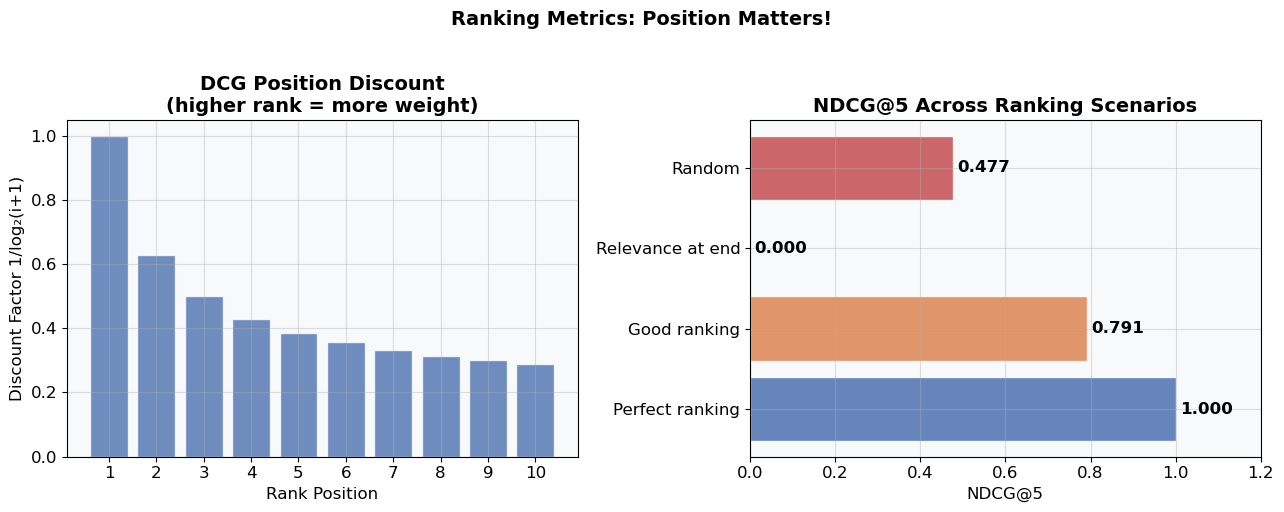

In [7]:
def precision_at_k(relevant, retrieved, k):
    """relevant: set of relevant item IDs, retrieved: ordered list of retrieved IDs."""
    top_k = retrieved[:k]
    return sum(1 for item in top_k if item in relevant) / k

def dcg_at_k(relevances, k):
    """relevances: list of relevance scores in ranked order."""
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    gains = relevances / np.log2(np.arange(2, len(relevances) + 2))
    return np.sum(gains)

def ndcg_at_k(relevances, k):
    dcg = dcg_at_k(relevances, k)
    ideal = dcg_at_k(sorted(relevances, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

# Example: movie recommendations (relevance: 0=bad, 1=ok, 2=great)
print("🎬 Movie Recommendation Example")
print("="*55)

scenarios = {
    'Perfect ranking':   [2, 2, 2, 1, 1, 0, 0, 0, 0, 0],
    'Good ranking':      [2, 1, 2, 0, 1, 0, 2, 0, 0, 0],
    'Relevance at end':  [0, 0, 0, 0, 0, 2, 2, 2, 1, 1],
    'Random':            [1, 0, 2, 0, 0, 1, 0, 2, 0, 0],
}

K = 5
print(f"{'Scenario':25s} | P@{K}  | DCG@{K} | NDCG@{K}")
print("-"*55)
for name, rels in scenarios.items():
    relevant_set = {i for i, r in enumerate(rels) if r > 0}
    retrieved = list(range(len(rels)))
    p_k = precision_at_k(relevant_set, retrieved, K)
    d = dcg_at_k(rels, K)
    n = ndcg_at_k(rels, K)
    print(f"{name:25s} | {p_k:.2f}  | {d:.2f}   | {n:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Show DCG discount curve
positions = np.arange(1, 11)
discounts = 1 / np.log2(positions + 1)
axes[0].bar(positions, discounts, color=COLORS[0], alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Rank Position'); axes[0].set_ylabel('Discount Factor 1/log₂(i+1)')
axes[0].set_title('DCG Position Discount\n(higher rank = more weight)')
axes[0].set_xticks(positions)

# Compare NDCG across scenarios
names = list(scenarios.keys())
ndcgs = [ndcg_at_k(rels, K) for rels in scenarios.values()]
bars = axes[1].barh(names, ndcgs, color=COLORS[:4], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, ndcgs):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontweight='bold')
axes[1].set_xlim(0, 1.2)
axes[1].set_xlabel('NDCG@5'); axes[1].set_title('NDCG@5 Across Ranking Scenarios')

plt.suptitle('Ranking Metrics: Position Matters!', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Calibration — Do Your Probabilities Actually Mean Anything?

A model might output `0.9` for a prediction, but does that actually mean 90% chance? **Calibration** measures whether predicted probabilities match real-world frequencies.

A **well-calibrated** model: among all predictions of ~0.8, about 80% should be positive.

**Why it matters:** In medicine, finance, or weather forecasting, you often need *reliable probabilities*, not just class labels.

The **reliability diagram** (calibration curve) plots:
- X-axis: mean predicted probability in a bin
- Y-axis: actual fraction of positives in that bin
- Perfect calibration: points on the diagonal

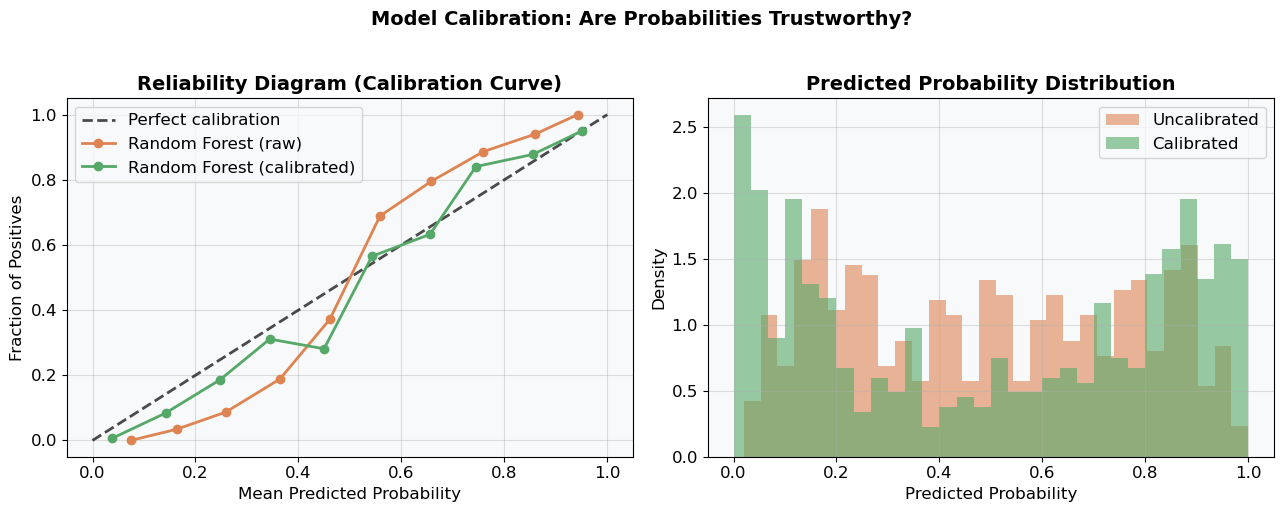

💡 Random forests tend to push probabilities toward 0.5 (underconfident).
   Calibration fixes this so 0.8 really means 80%.


In [8]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

X_cal, y_cal = make_classification(n_samples=2000, n_features=15, 
                                    n_informative=8, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cal, y_cal, test_size=0.4, random_state=42)

# Train models
rf_uncal = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_tr_c, y_tr_c)
rf_cal   = CalibratedClassifierCV(RandomForestClassifier(n_estimators=50, random_state=42),
                                   method='isotonic', cv=3).fit(X_tr_c, y_tr_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curves
ax = axes[0]
ax.plot([0,1], [0,1], 'k--', linewidth=2, label='Perfect calibration', alpha=0.7)

for model, name, color in [(rf_uncal, 'Random Forest (raw)', COLORS[1]),
                             (rf_cal, 'Random Forest (calibrated)', COLORS[2])]:
    probs = model.predict_proba(X_te_c)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_te_c, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', label=name, color=color, linewidth=2, markersize=6)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Reliability Diagram (Calibration Curve)')
ax.legend()

# Probability distribution comparison
ax = axes[1]
probs_uncal = rf_uncal.predict_proba(X_te_c)[:, 1]
probs_cal   = rf_cal.predict_proba(X_te_c)[:, 1]

ax.hist(probs_uncal, bins=30, alpha=0.6, color=COLORS[1], label='Uncalibrated', density=True)
ax.hist(probs_cal,   bins=30, alpha=0.6, color=COLORS[2], label='Calibrated',   density=True)
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution')
ax.legend()

plt.suptitle('Model Calibration: Are Probabilities Trustworthy?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Random forests tend to push probabilities toward 0.5 (underconfident).")
print("   Calibration fixes this so 0.8 really means 80%.")

---
## 8. Cross-Validation — Evaluating *Reliably*

A single train/test split is **noisy**. You might get lucky (or unlucky) with your split.  
**Cross-validation** gives you a much more reliable estimate of how well your model generalizes.

### K-Fold Cross-Validation
1. Split data into K equal folds
2. Train on K-1 folds, evaluate on the held-out fold
3. Repeat K times, each fold gets to be the test set once
4. Report mean ± std of the metric

**Stratified K-Fold**: preserves class proportions in each fold — always use this for imbalanced data.

**Rule of thumb**: K=5 or K=10. With small datasets, use Leave-One-Out (K=n).

### Cross-validation estimates
$$\text{CV score} = \frac{1}{K} \sum_{k=1}^{K} \text{metric}_k \qquad \text{std} = \sqrt{\frac{1}{K-1}\sum_{k=1}^{K}(\text{metric}_k - \overline{\text{metric}})^2}$$

Model                     Metric           Mean      Std
---------------------------------------------------------
Logistic Regression       accuracy        0.904 ± 0.026
Logistic Regression       f1              0.735 ± 0.074
Logistic Regression       roc_auc         0.904 ± 0.055
Logistic Regression       precision       0.848 ± 0.105
Logistic Regression       recall          0.657 ± 0.092

Random Forest             accuracy        0.934 ± 0.020
Random Forest             f1              0.806 ± 0.072
Random Forest             roc_auc         0.954 ± 0.012
Random Forest             precision       0.977 ± 0.028
Random Forest             recall          0.696 ± 0.113



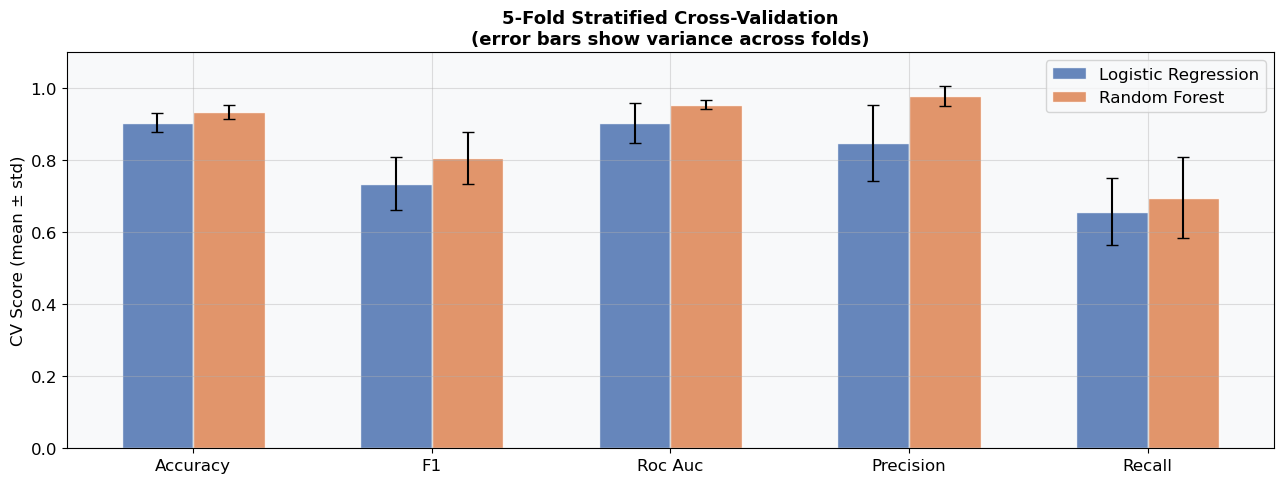

💡 High std → metric is unstable (could be lucky/unlucky on a single split)
   Always report mean ± std, not just the mean!


In [9]:
X_cv, y_cv = make_classification(n_samples=500, n_features=10, n_informative=5,
                                  weights=[0.8, 0.2], random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=50, random_state=42),
}

metrics_to_check = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_cv = {}
print(f"{'Model':25s} {'Metric':12s} {'Mean':>8s} {'Std':>8s}")
print("-" * 57)

for model_name, model in models.items():
    results_cv[model_name] = {}
    for metric in metrics_to_check:
        scores = cross_val_score(model, X_cv, y_cv, cv=skf, scoring=metric)
        results_cv[model_name][metric] = scores
        print(f"{model_name:25s} {metric:12s} {scores.mean():8.3f} ± {scores.std():5.3f}")
    print()

# Visualize CV scores
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(metrics_to_check))
width = 0.3

for i, (model_name, scores_dict) in enumerate(results_cv.items()):
    means = [scores_dict[m].mean() for m in metrics_to_check]
    stds  = [scores_dict[m].std()  for m in metrics_to_check]
    bars = ax.bar(x + i*width - width/2, means, width=width,
                  label=model_name, color=COLORS[i], alpha=0.85, edgecolor='white')
    ax.errorbar(x + i*width - width/2, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_check])
ax.set_ylabel('CV Score (mean ± std)')
ax.set_title('5-Fold Stratified Cross-Validation\n(error bars show variance across folds)', fontsize=13)
ax.legend(); ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print("💡 High std → metric is unstable (could be lucky/unlucky on a single split)")
print("   Always report mean ± std, not just the mean!")

---
## 9. The Decision Guide — Which Metric Do I Use?

This is the most practical thing in the notebook. In interviews, you'll be asked *"what metric would you use for X?"* Here's a cheat sheet.

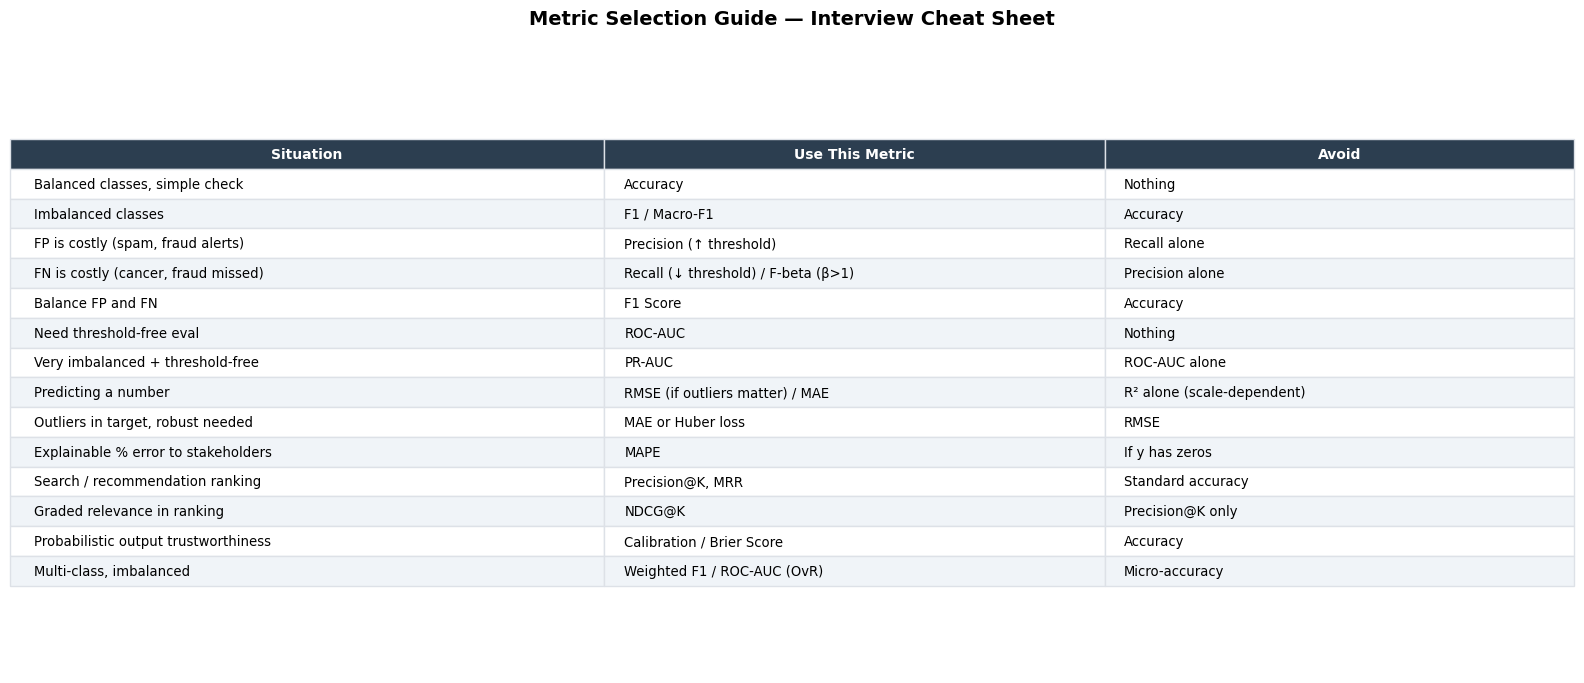

In [10]:
guide = {
    'Situation': [
        'Balanced classes, simple check',
        'Imbalanced classes',
        'FP is costly (spam, fraud alerts)',
        'FN is costly (cancer, fraud missed)',
        'Balance FP and FN',
        'Need threshold-free eval',
        'Very imbalanced + threshold-free',
        'Predicting a number',
        'Outliers in target, robust needed',
        'Explainable % error to stakeholders',
        'Search / recommendation ranking',
        'Graded relevance in ranking',
        'Probabilistic output trustworthiness',
        'Multi-class, imbalanced',
    ],
    'Use This Metric': [
        'Accuracy',
        'F1 / Macro-F1',
        'Precision (↑ threshold)',
        'Recall (↓ threshold) / F-beta (β>1)',
        'F1 Score',
        'ROC-AUC',
        'PR-AUC',
        'RMSE (if outliers matter) / MAE',
        'MAE or Huber loss',
        'MAPE',
        'Precision@K, MRR',
        'NDCG@K',
        'Calibration / Brier Score',
        'Weighted F1 / ROC-AUC (OvR)',
    ],
    'Avoid': [
        'Nothing',
        'Accuracy',
        'Recall alone',
        'Precision alone',
        'Accuracy',
        'Nothing',
        'ROC-AUC alone',
        'R² alone (scale-dependent)',
        'RMSE',
        'If y has zeros',
        'Standard accuracy',
        'Precision@K only',
        'Accuracy',
        'Micro-accuracy',
    ]
}

# Display as a nice table
import pandas as pd
df_guide = pd.DataFrame(guide)

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')

col_widths = [0.38, 0.32, 0.30]
table = ax.table(
    cellText=df_guide.values,
    colLabels=df_guide.columns,
    cellLoc='left',
    loc='center',
    colWidths=col_widths
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    elif row % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#dde1e7')
    cell.PAD = 0.04

plt.title('Metric Selection Guide — Interview Cheat Sheet',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 10. 🎤 Interview Q&A

---

**Q1: Your model has 99% accuracy. Is it good?**

**A:** Not necessarily. If the dataset is imbalanced (e.g., 99% negatives), a model that always predicts negative gets 99% accuracy while being completely useless. Always check class distribution and use Precision, Recall, F1, or ROC-AUC alongside accuracy.

---

**Q2: What's the difference between Precision and Recall? When do you prioritize each?**

**A:** 
- **Precision** = of all my positive predictions, how many were correct → prioritize when false positives are expensive (spam filter: don't delete real emails; fraud alerts: don't block real customers)
- **Recall** = of all actual positives, how many did I find → prioritize when false negatives are expensive (cancer screening: never miss a sick patient; fraud detection: don't let fraud slip through)

There's always a tradeoff: increasing one typically decreases the other by moving the classification threshold.

---

**Q3: What is ROC-AUC and what does it measure?**

**A:** ROC-AUC summarizes model performance across all classification thresholds. Concretely, it equals the probability that a randomly chosen positive example is scored higher than a randomly chosen negative example. AUC=0.5 means random, AUC=1.0 means perfect. It's threshold-independent, which makes it great for model comparison.

---

**Q4: When would you prefer PR-AUC over ROC-AUC?**

**A:** With highly imbalanced datasets. ROC-AUC can look optimistic because it accounts for True Negatives (which are abundant in imbalanced data). PR-AUC focuses only on the positive class — it penalizes the model for false positives more harshly, giving a more honest picture of performance on the rare class.

---

**Q5: Why is RMSE more sensitive to outliers than MAE?**

**A:** Because RMSE squares the errors before averaging. A single large error (e.g., 100 vs 10) contributes $100^2=10,000$ to MSE but only $|100|=100$ to MAE. Use RMSE when large errors are disproportionately bad (e.g., financial losses scale non-linearly). Use MAE when all errors are treated equally.

---

**Q6: What is model calibration and why does it matter?**

**A:** A calibrated model produces probabilities that reflect true likelihoods — if it says 0.8 for 1,000 examples, ~800 should actually be positive. Calibration matters in domains where you act on probabilities, not just class labels: medical diagnosis, insurance pricing, weather forecasting, risk scoring. Random Forests and SVMs are typically poorly calibrated; Logistic Regression is naturally well-calibrated. Isotonic regression or Platt scaling can fix it.

---

**Q7: What is NDCG and when do you use it?**

**A:** NDCG (Normalized Discounted Cumulative Gain) measures ranking quality, accounting for both relevance and position. It rewards putting highly relevant items at the top (via log discount) and normalizes to [0,1] by dividing by the ideal ranking score. Use it for search engines, recommendation systems, or any problem where the order of results matters — especially with graded relevance (not just relevant/irrelevant).

---

**Q8: What does R² = 0 or R² < 0 mean?**

**A:** R²=0 means your model does no better than always predicting the mean of y. R²<0 means your model is actually *worse* than predicting the mean — it's adding noise rather than signal. This can happen when your model severely overfits the training set or the test distribution is very different.

---

**Q9: What is cross-validation and why use it instead of a single train/test split?**

**A:** Cross-validation repeatedly splits data into training and validation sets, rotates which part is held out, and averages the metric across all splits. A single split gives a noisy estimate — you might get a lucky or unlucky split. CV reduces this variance and gives a more reliable picture of out-of-sample performance. It also makes better use of limited data since every sample gets to be in the test set exactly once.

---

**Q10: I have a fraud detection model. What metric would you pick and why?**

**A:** It depends on the business cost structure, but a good default is **PR-AUC** (because fraud is rare, so imbalanced data makes ROC-AUC optimistic) combined with **Recall** at an operationally acceptable Precision threshold. The business usually has a specific budget for false positives (how many real customers can you block?) and a tolerance for false negatives (how much fraud can you miss?). From these, you set the threshold and report F-beta or the resulting Precision/Recall pair.

---
## Summary

| Metric | Formula | When to use |
|--------|---------|-------------|
| Accuracy | (TP+TN)/All | Balanced classes only |
| Precision | TP/(TP+FP) | FP is costly |
| Recall | TP/(TP+FN) | FN is costly |
| F1 | Harmonic mean(P,R) | Imbalanced, both FP and FN matter |
| ROC-AUC | Area under ROC | General model comparison |
| PR-AUC | Area under PR curve | Imbalanced + rare class focus |
| MAE | mean|error| | Regression, outlier-robust |
| RMSE | √mean(error²) | Regression, penalize large errors |
| R² | 1 - SS_res/SS_tot | Regression, explained variance |
| MAPE | mean|%error| | Regression, interpretable % |
| Precision@K | hits/K | Recommendation top-K |
| NDCG@K | DCG/IDCG | Ranked retrieval, graded relevance |
| Calibration | reliability diagram | Probability trustworthiness |

**The golden rule**: always align your metric with the business cost of errors. What's worse — a false alarm or a miss? Your metric should reflect that answer.